# Nivel Esencial - Modelado: TF-IDF + Clasificador

Este notebook cubre:
1. Carga del dataset preprocesado
2. Vectorización con TF-IDF
3. División train/test
4. Entrenamiento de modelos (Logistic Regression y SVM)
5. Evaluación y control de overfitting
6. Guardado del modelo

> **Requisito del nivel esencial:** diferencia entre métricas de train y test inferior a 5 puntos porcentuales.

## 1. Carga del Dataset Preprocesado

Cargamos el CSV generado en el notebook anterior (`01_EDA_y_Preprocesamiento.ipynb`).  
Si no lo has ejecutado aún, hazlo primero para generar `data/processed/dataset_procesado.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset preprocesado
df = pd.read_csv("../data/processed/dataset_procesado.csv")

TEXT_COL  = "text_processed"  # texto limpio y lematizado
LABEL_COL = "IsToxic"         # 1 = tóxico, 0 = no tóxico

print(f"Filas cargadas: {len(df)}")
print(f"Distribución de clases:\n{df[LABEL_COL].value_counts()}")
print(f"\nEjemplo de texto procesado:\n{df[TEXT_COL].iloc[0]}")

X = df[TEXT_COL].fillna("")
y = df[LABEL_COL]

Filas cargadas: 998
Distribución de clases:
IsToxic
0    537
1    461
Name: count, dtype: int64

Ejemplo de texto procesado:
people would take step back make case wasnt anyone except two people situation lump mess take matter hand make kind protest selfish without rational thought investigation guy video heavily emotional hyped want heard get heard press never reasonable discussion kudos smerconish keeping level whole time letting masri make fool dare tore city protest make dishonor entire incident hate way since police brutality become epidemic wish everyone would stop pretending like knew exactly going there measurable amount people honestly witnessed incident none u clue way whole issue swung grand jury informed trust majority rule right course action let also thank police officer america actually serve protect even youre bit jerk pull respect job know someone many people going pout held accountable action people hate police need officer two around emergency


## 2. Vectorización con TF-IDF

### ¿Por qué necesitamos vectorizar?
Los modelos de ML no entienden texto directamente, solo números.  
**TF-IDF** convierte cada comentario en un vector numérico.

### ¿Cómo funciona TF-IDF?
Asigna un peso a cada palabra según dos factores:

| Componente | Qué mide | Efecto |
|------------|----------|--------|
| **TF** (Term Frequency) | Con qué frecuencia aparece una palabra en un comentario | Palabras repetidas en un comentario tienen más peso |
| **IDF** (Inverse Document Frequency) | En cuántos comentarios aparece esa palabra | Palabras que aparecen en todos los comentarios (ej: "the") tienen menos peso |

**Resultado:** palabras raras pero relevantes (como insultos específicos) tienen peso alto. Palabras comunes tienen peso bajo.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# --- División train/test ANTES de vectorizar (evita data leakage) ---
# 80% entrenamiento, 20% test
# stratify=y → mantiene la misma proporción de clases en ambos splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train_raw)} comentarios")
print(f"Test:          {len(X_test_raw)} comentarios")
print(f"\nDistribución train:\n{y_train.value_counts()}")
print(f"\nDistribución test:\n{y_test.value_counts()}")

# --- TF-IDF ---
# max_features: limitamos el vocabulario a las 10.000 palabras más relevantes
# ngram_range=(1,2): incluye palabras sueltas Y pares de palabras ("hate speech")
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True  # aplica log(tf) para suavizar frecuencias muy altas
)

# fit_transform en train (aprende el vocabulario y transforma)
X_train = tfidf.fit_transform(X_train_raw)
# transform en test (solo transforma, NO vuelve a aprender)
X_test  = tfidf.transform(X_test_raw)

print(f"\nMatriz TF-IDF train: {X_train.shape}  → ({X_train.shape[0]} comentarios, {X_train.shape[1]} palabras)")
print(f"Matriz TF-IDF test:  {X_test.shape}")

Entrenamiento: 798 comentarios
Test:          200 comentarios

Distribución train:
IsToxic
0    429
1    369
Name: count, dtype: int64

Distribución test:
IsToxic
0    108
1     92
Name: count, dtype: int64

Matriz TF-IDF train: (798, 10000)  → (798 comentarios, 10000 palabras)
Matriz TF-IDF test:  (200, 10000)


## 3. Entrenamiento y Evaluación de Modelos

Entrenamos dos clasificadores clásicos y comparamos su rendimiento:

| Modelo | Ventajas |
|--------|----------|
| **Logistic Regression** | Rápido, interpretable, buen baseline para texto |
| **SVM (LinearSVC)** | Muy potente en espacios de alta dimensión como TF-IDF |

### Métricas que usamos
- **Accuracy**: porcentaje de predicciones correctas
- **Precision**: de los que predijo como tóxicos, ¿cuántos lo eran realmente?
- **Recall**: de todos los tóxicos reales, ¿cuántos detectó?
- **F1-score**: media armónica de precision y recall (la más importante en datasets desbalanceados)

### Control de overfitting
El nivel esencial exige que la diferencia entre métricas de **train y test sea < 5 puntos porcentuales**.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    """
    Entrena el modelo, evalúa en train y test,
    e imprime métricas + control de overfitting.
    """
    model.fit(X_tr, y_tr)

    # Predicciones
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # Métricas
    acc_train = accuracy_score(y_tr, y_pred_train) * 100
    acc_test  = accuracy_score(y_te, y_pred_test)  * 100
    f1_train  = f1_score(y_tr, y_pred_train) * 100
    f1_test   = f1_score(y_te, y_pred_test)  * 100

    gap_acc = acc_train - acc_test
    gap_f1  = f1_train  - f1_test

    print(f"\n{'='*55}")
    print(f"  Modelo: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  — Train: {acc_train:.1f}%  |  Test: {acc_test:.1f}%  |  Gap: {gap_acc:.1f}%")
    print(f"  F1-score  — Train: {f1_train:.1f}%  |  Test: {f1_test:.1f}%  |  Gap: {gap_f1:.1f}%")

    # Control de overfitting
    if gap_acc <= 5 and gap_f1 <= 5:
        print(f"  Overfitting: OK (gap <= 5 puntos)")
    else:
        print(f"  Overfitting: ALERTA (gap > 5 puntos) — ajustar regularizacion")

    print(f"\n  Reporte completo (Test):")
    print(classification_report(y_te, y_pred_test,
                                target_names=["No toxico", "Toxico"]))
    return model, y_pred_test

# --- Logistic Regression ---
# C=1.0: parámetro de regularización (menor C = más regularización = menos overfitting)
lr_model, lr_preds = evaluate_model(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    X_train, X_test, y_train, y_test,
    "Logistic Regression"
)

# --- LinearSVC ---
# C=0.5: regularización moderada para controlar overfitting
svm_model, svm_preds = evaluate_model(
    LinearSVC(C=0.5, max_iter=2000, random_state=42),
    X_train, X_test, y_train, y_test,
    "LinearSVC"
)


  Modelo: Logistic Regression
  Accuracy  — Train: 98.5%  |  Test: 71.0%  |  Gap: 27.5%
  F1-score  — Train: 98.4%  |  Test: 64.6%  |  Gap: 33.7%
  Overfitting: ALERTA (gap > 5 puntos) — ajustar regularizacion

  Reporte completo (Test):
              precision    recall  f1-score   support

   No toxico       0.70      0.82      0.75       108
      Toxico       0.74      0.58      0.65        92

    accuracy                           0.71       200
   macro avg       0.72      0.70      0.70       200
weighted avg       0.71      0.71      0.70       200




  Modelo: LinearSVC
  Accuracy  — Train: 99.9%  |  Test: 72.0%  |  Gap: 27.9%
  F1-score  — Train: 99.9%  |  Test: 67.1%  |  Gap: 32.8%
  Overfitting: ALERTA (gap > 5 puntos) — ajustar regularizacion

  Reporte completo (Test):
              precision    recall  f1-score   support

   No toxico       0.71      0.81      0.76       108
      Toxico       0.73      0.62      0.67        92

    accuracy                           0.72       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.72      0.72       200



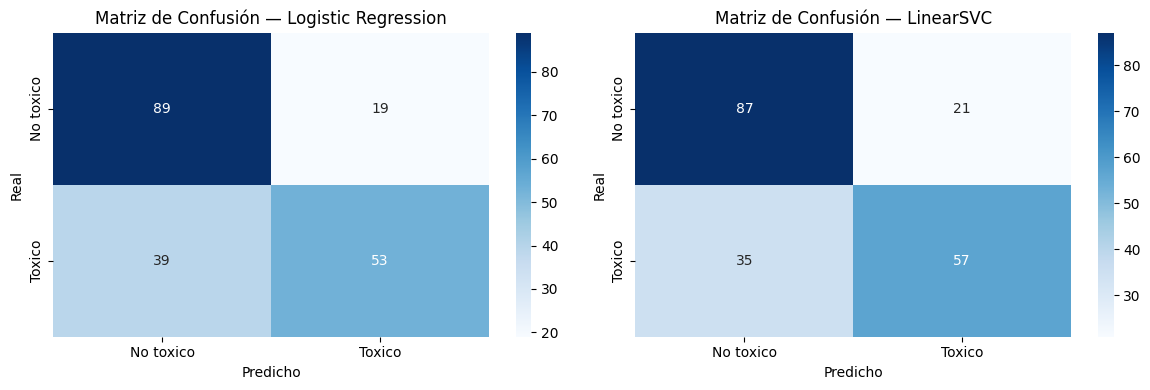

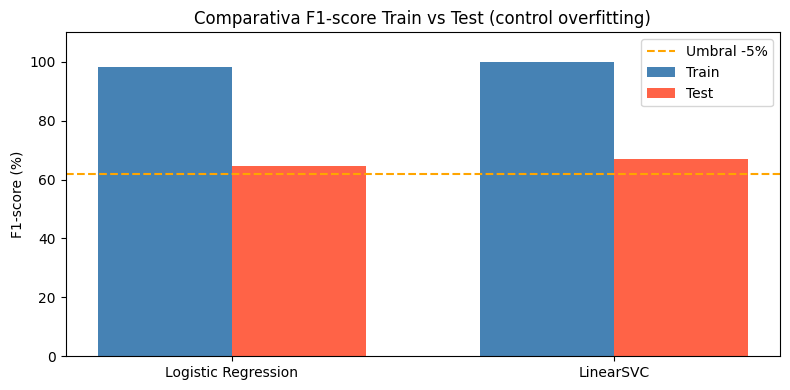

In [4]:
# --- Matrices de confusión ---
# La matriz de confusión muestra cuántos aciertos y errores tiene el modelo por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [lr_preds, svm_preds],
    ["Logistic Regression", "LinearSVC"]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No toxico", "Toxico"],
                yticklabels=["No toxico", "Toxico"])
    ax.set_title(f"Matriz de Confusión — {title}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.show()

# --- Comparativa F1-score train vs test ---
models_names = ["Logistic Regression", "LinearSVC"]
models_list  = [lr_model, svm_model]

f1_trains, f1_tests = [], []
for m in models_list:
    f1_trains.append(f1_score(y_train, m.predict(X_train)) * 100)
    f1_tests.append( f1_score(y_test,  m.predict(X_test))  * 100)

x = np.arange(len(models_names))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, f1_trains, width, label="Train", color="steelblue")
ax.bar(x + width/2, f1_tests,  width, label="Test",  color="tomato")
ax.set_ylabel("F1-score (%)")
ax.set_title("Comparativa F1-score Train vs Test (control overfitting)")
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.axhline(y=max(f1_tests) - 5, color="orange", linestyle="--", label="Umbral -5%")
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

## 4. Guardado del Modelo

Guardamos el modelo con mejor F1-score en test junto con el vectorizador TF-IDF.  
Es **imprescindible guardar ambos** porque para predecir un texto nuevo necesitamos:
1. El **TF-IDF** para transformar el texto al mismo espacio vectorial
2. El **modelo** para clasificarlo

In [5]:
import joblib
import os

# Seleccionar el mejor modelo según F1 en test
best_idx   = int(np.argmax(f1_tests))
best_model = models_list[best_idx]
best_name  = models_names[best_idx]

print(f"Mejor modelo: {best_name}  (F1 test: {f1_tests[best_idx]:.1f}%)")

# Guardar modelo y vectorizador
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/trained_model.pkl")
joblib.dump(tfidf,      "../models/tfidf_vectorizer.pkl")

print("\nGuardado:")
print("  ../models/trained_model.pkl")
print("  ../models/tfidf_vectorizer.pkl")

# Verificación: cargar y predecir un comentario de prueba
model_loaded = joblib.load("../models/trained_model.pkl")
tfidf_loaded = joblib.load("../models/tfidf_vectorizer.pkl")

test_comments = [
    "I hate you, you are the worst person ever",
    "This is a great video, very informative and helpful!"
]

for comment in test_comments:
    vec = tfidf_loaded.transform([comment])
    pred = model_loaded.predict(vec)[0]
    label = "TOXICO" if pred == 1 else "No toxico"
    print(f"\nComentario: {comment}")
    print(f"Prediccion: {label}")

Mejor modelo: LinearSVC  (F1 test: 67.1%)

Guardado:
  ../models/trained_model.pkl
  ../models/tfidf_vectorizer.pkl



Comentario: I hate you, you are the worst person ever
Prediccion: No toxico

Comentario: This is a great video, very informative and helpful!
Prediccion: No toxico
